# Data Preprocessing

In [2]:
import pandas as pd
import os
import os.path as osp
import csv

In [3]:
log_path = "data/data.txt"
name_list = ["reno", "tri", "mario", "nopal"]
min_len_columns = 31 # pake minimum karena ada tim tri totalnya ga sama, harusnya 32

In [ ]:
def write_column_names_to_csv(column_names, csv_path):
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(column_names)
        
def write_line_to_csv(line, csv_path):
    with open(csv_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(line)

In [ ]:
for name in name_list:
    csv_path = f"data/output_{name}.csv"
    if osp.exists(csv_path):
        os.remove(csv_path)

# Clear old generated CSVs so rerunning this cell does not append duplicate rows.
with open(log_path, "r", encoding="utf-16", errors="ignore") as file:
    name_counter = 0
    is_numerical_data = False
    is_real_flight = False
    column_names = list()

    for line in file:
        lines = [ln.strip().replace("|", "") for ln in line.split("|")]
        lines.pop()

        if len(lines) == 0:
            continue

        # check if it's the actual flight data not empty data yang dikosongin mufty
        # "f-act,_/sec" condition because for some reason tim nopal ada column itu
        if len(lines) >= min_len_columns and 'f-act,_/sec' not in lines:
            is_real_flight = True
        else:
            is_real_flight = False
            # continue
        
        # check if there's a numerical data in the line, because if it's not, it's a column name
        try:
            is_numerical_data = True if float(lines[0]) else False
        except ValueError:
            is_numerical_data = False
        
        if len(column_names) == 0 and is_real_flight:
            column_names = [ln.replace("_","") for ln in lines]
            print(column_names)
        
        # condition when the real flight data has ended and the next lines are the empty data from mufty, > 0 is to avoid the first set condition
        if len(column_names) > 0 and not is_numerical_data and not is_real_flight:
            finished_name = name_list[name_counter]
            name_counter += 1
            if name_counter < len(name_list):
                print(f"Finished processing {finished_name}. Moving to {name_list[name_counter]}...")
            else:
                print(f"Finished processing {finished_name}.")
            column_names = list()

        if is_numerical_data and is_real_flight and len(column_names) > 0 and name_counter < len(name_list):
            csv_path = f"data/output_{name_list[name_counter]}.csv"
            if not osp.exists(csv_path):
                os.makedirs(osp.dirname(csv_path), exist_ok=True)
                write_line_to_csv(column_names, csv_path)
            write_line_to_csv(lines, csv_path)
        
        # Uncomment this while debugging the parser.
        # print(f"is_numerical_data: {is_numerical_data}, is_real_flight: {is_real_flight}, lines: {lines}")


# Analysis

## Goal
This section turns the cleaned Mario dataset into the items requested in the assignment: grouped takeoff maneuvers, elevator/altitude/airspeed/distance plots, takeoff distance per maneuver, summary statistics, and report notes.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [23]:
DATA_PATH = Path("data/output_mario.csv")
FIGURE_DIR = Path("figures")
SUMMARY_PATH = Path("data/mario_takeoff_summary.csv")

TARGET_ALT_FT = 100.0

TAKEOFF_RUN_LIMIT = None

# Raw mission 2 was the first actual takeoff, because i was trying to familiarize with the control lol.
MANUAL_EXCLUDED_RAW_MISSION_IDS = {2}

MISSION_TIME_COL = "missn,time"
ALTITUDE_COL = "alt,ftagl"
AIRSPEED_COL = "Vind,kias"
ELEVATOR_COL = "elev,surf"
LAT_COL = "lat,deg"
LON_COL = "lon,deg"

## Mission Grouping
X-Plane resets `missn,time` to nearly zero after each mission restart. A new raw mission is therefore detected whenever `missn,time` decreases. The first raw segment in our file does not climb above the target altitude, so it is treated as setup/aborted data. Raw mission 2 is also excluded because it was a control-familiarization run before the repeatable takeoff procedure.

In [24]:
data = pd.read_csv(DATA_PATH)

required_columns = [MISSION_TIME_COL, ALTITUDE_COL, AIRSPEED_COL, ELEVATOR_COL, LAT_COL, LON_COL]
missing_columns = [column for column in required_columns if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = data.sort_values("real,time").reset_index(drop=True)
data["raw_mission_id"] = data[MISSION_TIME_COL].diff().lt(0).cumsum() + 1

raw_mission_summary = (
    data.groupby("raw_mission_id")
    .agg(
        rows=(MISSION_TIME_COL, "size"),
        start_mission_time_s=(MISSION_TIME_COL, "first"),
        end_mission_time_s=(MISSION_TIME_COL, "last"),
        max_altitude_ftagl=(ALTITUDE_COL, "max"),
        max_airspeed_kias=(AIRSPEED_COL, "max"),
    )
    .reset_index()
)

raw_mission_summary.round(2)

,raw_mission_id,rows,start_mission_time_s,end_mission_time_s,max_altitude_ftagl,max_airspeed_kias
0,1,888,0.00,88.71,0.42,51.90
1,2,776,0.05,77.59,133.43,92.47
2,3,328,0.09,32.86,131.72,99.00
3,4,364,0.00,36.28,138.51,90.28
4,5,381,0.00,37.95,139.97,89.44
5,6,366,0.10,36.58,150.00,89.76
6,7,378,0.00,37.68,146.70,87.10
7,8,327,0.10,32.70,144.18,87.31
8,9,324,0.09,32.34,139.34,85.21
9,10,335,0.10,33.46,140.61,85.24


In [25]:
valid_raw_missions = raw_mission_summary.loc[
    raw_mission_summary["max_altitude_ftagl"] >= TARGET_ALT_FT,
    "raw_mission_id",
].tolist()

valid_raw_missions = [
    raw_id for raw_id in valid_raw_missions
    if raw_id not in MANUAL_EXCLUDED_RAW_MISSION_IDS
]

if TAKEOFF_RUN_LIMIT is not None:
    valid_raw_missions = valid_raw_missions[:TAKEOFF_RUN_LIMIT]

mission_id_map = {raw_id: maneuver_id for maneuver_id, raw_id in enumerate(valid_raw_missions, start=1)}
runs = data[data["raw_mission_id"].isin(valid_raw_missions)].copy()
runs["maneuver_id"] = runs["raw_mission_id"].map(mission_id_map)
runs["time_s"] = runs.groupby("maneuver_id")[MISSION_TIME_COL].transform(lambda series: series - series.iloc[0])

print(f"Detected {raw_mission_summary.shape[0]} raw mission segments.")
print(f"Keeping {len(valid_raw_missions)} valid takeoff maneuvers that reach at least {TARGET_ALT_FT:.0f} ft AGL.")
print(f"Manual familiarization exclusions: {sorted(MANUAL_EXCLUDED_RAW_MISSION_IDS)}")
print(f"Excluded raw mission ids: {sorted(set(raw_mission_summary['raw_mission_id']) - set(valid_raw_missions))}")

Detected 12 raw mission segments.
Keeping 10 valid takeoff maneuvers that reach at least 100 ft AGL.
Manual familiarization exclusions: [2]
Excluded raw mission ids: [1, 2]


## Distance Calculation
Distance traveled is computed as cumulative horizontal ground-track distance from the latitude/longitude samples. This is better than only measuring straight-line displacement because it follows the recorded path of the aircraft.

In [26]:
EARTH_RADIUS_M = 6_371_000.0
M_TO_FT = 3.280839895


def add_cumulative_ground_distance(segment: pd.DataFrame) -> pd.DataFrame:
    segment = segment.copy()
    lat_rad = np.radians(segment[LAT_COL].to_numpy())
    lon_rad = np.radians(segment[LON_COL].to_numpy())

    dlat = np.diff(lat_rad, prepend=lat_rad[0])
    dlon = np.diff(lon_rad, prepend=lon_rad[0])
    mean_lat = np.empty_like(lat_rad)
    mean_lat[0] = lat_rad[0]
    mean_lat[1:] = (lat_rad[1:] + lat_rad[:-1]) / 2

    dx = EARTH_RADIUS_M * dlon * np.cos(mean_lat)
    dy = EARTH_RADIUS_M * dlat
    segment["distance_step_m"] = np.sqrt(dx**2 + dy**2)
    segment["distance_m"] = segment["distance_step_m"].cumsum()
    segment["distance_ft"] = segment["distance_m"] * M_TO_FT
    return segment


runs = pd.concat(
    [add_cumulative_ground_distance(segment) for _, segment in runs.groupby("maneuver_id", sort=True)],
    ignore_index=True,
)

runs[["maneuver_id", "time_s", ALTITUDE_COL, AIRSPEED_COL, ELEVATOR_COL, "distance_m"]].head()

,maneuver_id,time_s,"alt,ftagl","Vind,kias","elev,surf",distance_m
0,1,0.00000,0.12286,0.00000,0.05488,0.0
1,1,0.09990,0.27935,0.00000,0.06473,0.0
2,1,0.19917,0.34102,0.00000,0.07252,0.0
3,1,0.29813,0.33865,0.00525,0.06625,0.0
4,1,0.39695,0.33532,0.02470,0.05448,0.0


## Takeoff Distance Table
The takeoff distance is interpolated at `TARGET_ALT_FT`. With the current data, 50 ft and 100 ft AGL are reachable for all valid runs.

In [27]:
def interpolate_at_altitude(segment: pd.DataFrame, target_alt_ft: float, value_col: str):
    altitude = segment[ALTITUDE_COL].to_numpy()
    values = segment[value_col].to_numpy()
    crossed_indices = np.flatnonzero(altitude >= target_alt_ft)

    if len(crossed_indices) == 0:
        return np.nan

    idx = crossed_indices[0]
    if idx == 0:
        return values[idx]

    alt_0, alt_1 = altitude[idx - 1], altitude[idx]
    if alt_1 == alt_0:
        return values[idx]

    fraction = (target_alt_ft - alt_0) / (alt_1 - alt_0)
    return values[idx - 1] + fraction * (values[idx] - values[idx - 1])


def first_time_at_threshold(segment: pd.DataFrame, col: str, threshold: float):
    values = segment[col].to_numpy()
    crossed_indices = np.flatnonzero(values >= threshold)
    if len(crossed_indices) == 0:
        return np.nan
    return segment["time_s"].to_numpy()[crossed_indices[0]]


metrics = []
for maneuver_id, segment in runs.groupby("maneuver_id", sort=True):
    metrics.append({
        "maneuver_id": maneuver_id,
        "duration_s": segment["time_s"].iloc[-1],
        "max_altitude_ftagl": segment[ALTITUDE_COL].max(),
        "max_airspeed_kias": segment[AIRSPEED_COL].max(),
        "time_at_target_s": interpolate_at_altitude(segment, TARGET_ALT_FT, "time_s"),
        "takeoff_distance_m": interpolate_at_altitude(segment, TARGET_ALT_FT, "distance_m"),
        "takeoff_distance_ft": interpolate_at_altitude(segment, TARGET_ALT_FT, "distance_ft"),
        "airspeed_at_target_kias": interpolate_at_altitude(segment, TARGET_ALT_FT, AIRSPEED_COL),
        "pitch_at_target_deg": interpolate_at_altitude(segment, TARGET_ALT_FT, "pitch,deg"),
        "liftoff_5ft_time_s": interpolate_at_altitude(segment, 5.0, "time_s"),
        "liftoff_5ft_distance_m": interpolate_at_altitude(segment, 5.0, "distance_m"),
        "distance_at_100ft_m": interpolate_at_altitude(segment, 100.0, "distance_m"),
        "distance_at_200ft_m": interpolate_at_altitude(segment, 200.0, "distance_m"),
        "end_distance_m": segment["distance_m"].iloc[-1],
        "end_altitude_ftagl": segment[ALTITUDE_COL].iloc[-1],
    })

takeoff_metrics = pd.DataFrame(metrics)
takeoff_metrics.to_csv(SUMMARY_PATH, index=False)
takeoff_metrics.round(2)

,maneuver_id,duration_s,max_altitude_ftagl,max_airspeed_kias,time_at_target_s,takeoff_distance_m,takeoff_distance_ft,airspeed_at_target_kias,pitch_at_target_deg,liftoff_5ft_time_s,liftoff_5ft_distance_m,distance_at_100ft_m,distance_at_200ft_m,end_distance_m,end_altitude_ftagl
0,1,32.76,131.72,99.00,30.37,875.96,2873.89,95.92,8.09,23.48,543.94,875.96,NaN,998.08,131.72
1,2,36.28,138.51,90.28,33.50,785.19,2576.09,87.60,6.62,26.45,472.80,785.19,NaN,914.33,138.51
2,3,37.95,139.97,89.44,35.19,769.49,2524.56,87.16,7.52,28.92,490.37,769.49,NaN,896.14,139.97
3,4,36.48,150.00,89.76,33.68,807.60,2649.61,88.51,8.53,27.53,529.99,807.60,NaN,937.10,150.00
4,5,37.68,146.70,87.10,35.01,743.31,2438.67,85.76,9.30,28.55,461.97,743.31,NaN,863.76,146.70
5,6,32.61,144.18,87.31,29.76,749.00,2457.33,85.32,8.55,23.65,483.18,749.00,NaN,876.78,144.18
6,7,32.24,139.34,85.21,30.07,728.41,2389.79,84.47,10.41,24.23,475.88,728.41,NaN,824.50,139.34
7,8,33.37,140.61,85.24,30.74,712.81,2338.62,83.52,9.32,24.81,460.02,712.81,NaN,828.29,140.61
8,9,32.64,147.49,86.96,29.64,748.43,2455.49,84.79,8.71,23.25,473.68,748.43,NaN,882.96,147.49
9,10,31.53,145.80,85.67,29.00,741.93,2434.14,84.61,9.95,22.86,477.64,741.93,NaN,853.41,145.80


In [28]:
distance_stats = pd.DataFrame({
    "takeoff_distance_m": takeoff_metrics["takeoff_distance_m"].agg(["mean", "min", "max", "std"]),
    "takeoff_distance_ft": takeoff_metrics["takeoff_distance_ft"].agg(["mean", "min", "max", "std"]),
})
distance_stats.loc["range"] = distance_stats.loc["max"] - distance_stats.loc["min"]
distance_stats.round(2)

,takeoff_distance_m,takeoff_distance_ft
mean,766.21,2513.82
min,712.81,2338.62
max,875.96,2873.89
std,47.30,155.19
range,163.15,535.26


## Required Plots
The next cells save report-ready plots into `figures/` and also display them in the notebook.

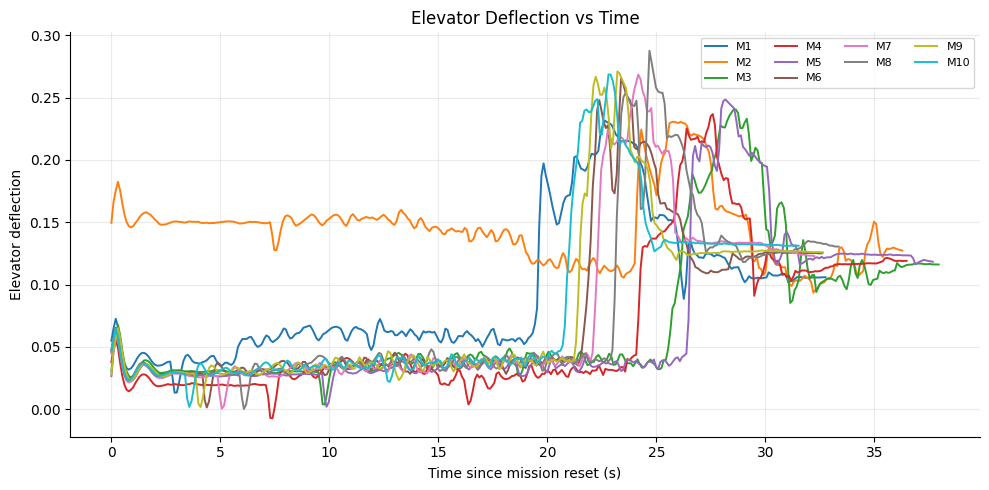

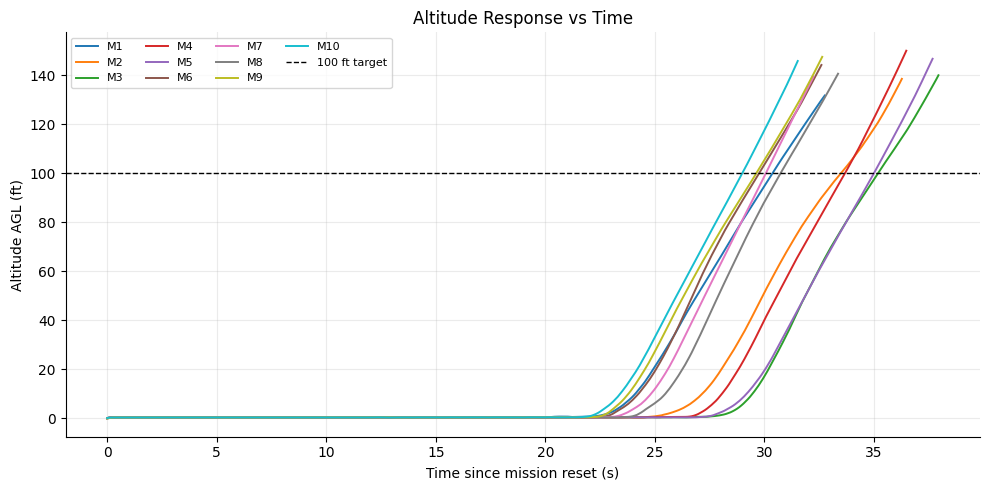

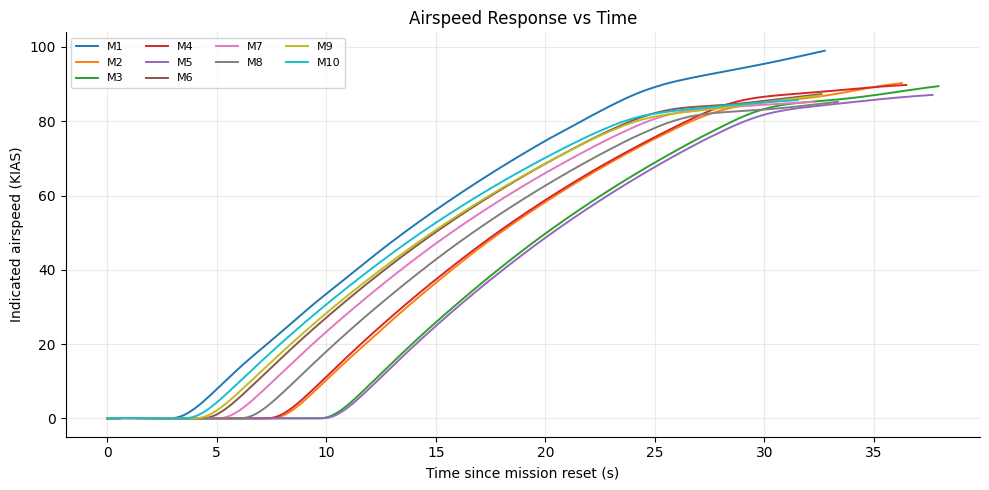

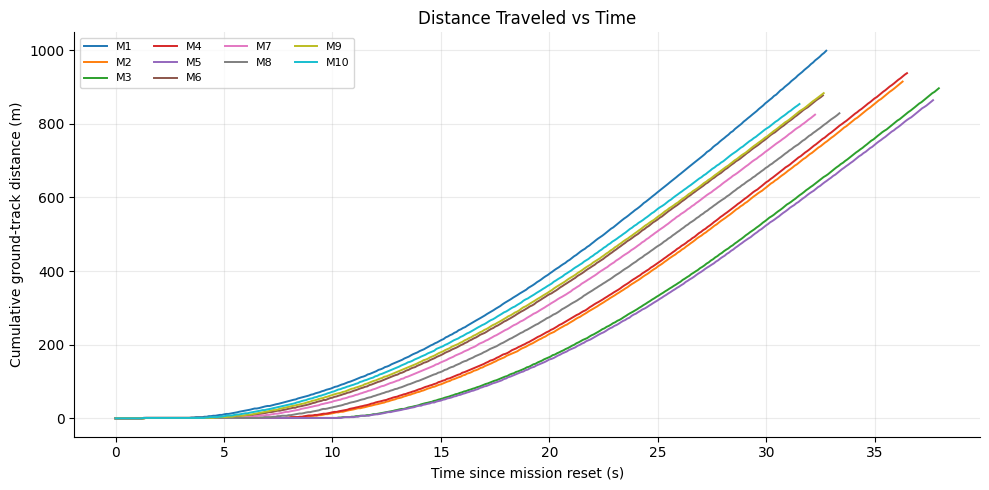

In [29]:
FIGURE_DIR.mkdir(exist_ok=True)


def plot_runs(y_col: str, y_label: str, title: str, filename: str, hline=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    for maneuver_id, segment in runs.groupby("maneuver_id", sort=True):
        ax.plot(segment["time_s"], segment[y_col], linewidth=1.4, label=f"M{maneuver_id}")

    if hline is not None:
        ax.axhline(hline, color="black", linestyle="--", linewidth=1.0, label=f"{hline:g} ft target")

    ax.set_title(title)
    ax.set_xlabel("Time since mission reset (s)")
    ax.set_ylabel(y_label)
    ax.legend(ncol=4, fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig, ax


plot_runs(ELEVATOR_COL, "Elevator deflection", "Elevator Deflection vs Time", "elevator_vs_time.png")
plot_runs(ALTITUDE_COL, "Altitude AGL (ft)", "Altitude Response vs Time", "altitude_vs_time.png", hline=TARGET_ALT_FT)
plot_runs(AIRSPEED_COL, "Indicated airspeed (KIAS)", "Airspeed Response vs Time", "airspeed_vs_time.png")
plot_runs("distance_m", "Cumulative ground-track distance (m)", "Distance Traveled vs Time", "distance_vs_time.png")
plt.show()

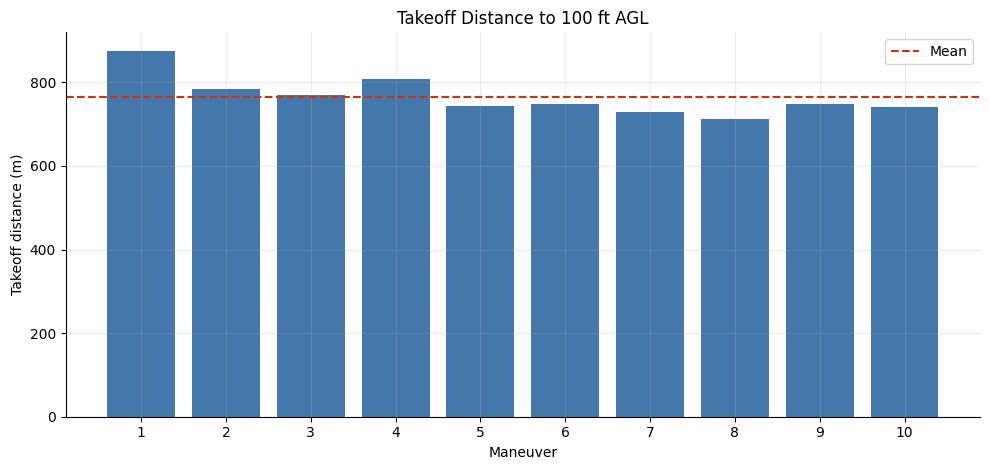

In [30]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(takeoff_metrics["maneuver_id"].astype(str), takeoff_metrics["takeoff_distance_m"], color="#4477AA")
ax.axhline(takeoff_metrics["takeoff_distance_m"].mean(), color="#CC3311", linestyle="--", linewidth=1.5, label="Mean")
ax.set_title(f"Takeoff Distance to {TARGET_ALT_FT:.0f} ft AGL")
ax.set_xlabel("Maneuver")
ax.set_ylabel("Takeoff distance (m)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "mario_takeoff_distance_by_maneuver.png", dpi=180, bbox_inches="tight")
plt.show()

## Fundamental Theory Notes
For the report, define takeoff distance as the horizontal distance from brake release/standing start until the aircraft reaches the chosen completion height. A useful decomposition is:

$S_{TO} = S_g + S_a$

where $S_g$ is the ground roll distance and $S_a$ is the airborne distance to the specified height. During ground roll, acceleration can be approximated from the force balance

$m \frac{dV}{dt} = T - D - \mu (W - L)$

so the distance can also be written as

$S_g = \int_0^{V_{LOF}} \frac{V}{a(V)}\,dV$

After lift-off, the initial climb distance depends mainly on climb angle, pitch/rotation technique, excess thrust, and the airspeed maintained during the climb. In this notebook the distance is not estimated from theory; it is measured from the simulator latitude/longitude data and interpolated at the selected target altitude.

## Report Analysis Notes
Use the table and plots above for the discussion section.

- Our file contains 12 raw mission segments. Raw mission 1 is setup/aborted data, and raw mission 2 is excluded as a control-familiarization run.
- The final report set therefore contains 10 repeatable takeoff maneuvers at the 100 ft target.
- Differences between maneuvers can come from rotation timing, elevator pull rate, how tightly 10 deg pitch was held, runway alignment, airspeed at rotation, and the exact moment the simulator reset/log started.
- For an Aircraft Flight Manual value, do not use the minimum distance. If every run followed the stated procedure, use the maximum measured distance or a rounded value above it. If a run is documented as nonrepresentative, exclude it transparently and use the maximum of the remaining valid runs plus a conservative margin.
- Pilot procedure wording can be: set takeoff flap configuration, hold aircraft aligned on runway threshold, apply full throttle, maintain runway centerline, rotate at the selected reference speed with a smooth pull to about 10 deg pitch, hold the target pitch through the selected obstacle height, then accelerate/climb normally.